In [114]:
import os
import numpy as np
import tensorflow as tf
import plotly.express as px
import matplotlib.pyplot as plt

import sys
sys.path.append("..") # Adds higher directory to python modules path.
from drought_detection.data_handling import parse_visual, get_img_from_example
from drought_detection.plotting import plot_sat_imgs, plot_sat_imgs_plt


In [73]:
# create a function called dirlist that extracts a list of file names (file) from a directory (di)
dirlist = lambda di: [os.path.join(di, file) for file in os.listdir(di) if 'part-' in file]

# get list of files
validation_files = dirlist('../raw_data/val/')

# parse first file (returns image as list of dict)
parsed_examples = parse_visual(validation_files[0:2])


In [74]:
# convert single image into matrix of numbers, select red and infrared bands
img, label = get_img_from_example(parsed_examples[0], bands=['B4','B5'])

In [75]:
# plot image with label as title
plot_sat_imgs(parsed_examples, channels=2, n_imgs=1)

# we can't do matrix math, because the matrices are inverted somehow?

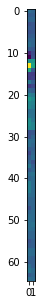

In [76]:
def normalized_difference(img, b1, b2, eps=0.0001):
    band1 = np.where((img[b1]==0) & (img[b2]==0), np.nan, img[b1])
    band2 = np.where((img[b1]==0) & (img[b2]==0), np.nan, img[b2])
    
    return (band1 - band2) / (band1 + band2)

# Calculating two indices
ndvi = normalized_difference(img, 0, 1)

# checking the images
fig = plt.figure(figsize=(10, 5))
plt.imshow(ndvi);


In [77]:

# function that selects bands (all in this case) and gets raw data as tensorflow object
def parse_visual(data, bands=['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11']):
    '''
    This function filters satellite image data by specific spectral bands (RGB in this case).
    The function loads a batch of satellite images from a list of files
    and parses the satellite image data files for some specific features,
    e.g. spectral bands (B2, B3, B4, see official documentation)

    Input(s): - list of satellite image files (including path, e.g '/data/train/part-r-00000')
    Outputs:  - list of dictionaries of raw satellite data (filtered by spectral band)
    '''
    dataset = tf.data.TFRecordDataset(data)

    iterator = tf.compat.v1.data.make_one_shot_iterator(dataset)
    
    features = {}
    
    for b in bands:
        features[b] = tf.compat.v1.FixedLenFeature([], tf.string)
    
    features['label'] = tf.compat.v1.FixedLenFeature([], tf.int64)

    # features = {
    #     'B1': tf.compat.v1.FixedLenFeature([], tf.string),    # 0.43 - 0.45 μm Coastal aerosol
    #     'B2': tf.compat.v1.FixedLenFeature([], tf.string),    # Blue
    #     'B3': tf.compat.v1.FixedLenFeature([], tf.string),    # Green
    #     'B4': tf.compat.v1.FixedLenFeature([], tf.string),    # Red
    #     'B5': tf.compat.v1.FixedLenFeature([], tf.string),    # Near infrared
    #     'B6': tf.compat.v1.FixedLenFeature([], tf.string),    # Shortwave infrared 1
    #     'B7': tf.compat.v1.FixedLenFeature([], tf.string),    # Shortwave infrared 2
    #     'B8': tf.compat.v1.FixedLenFeature([], tf.string),
    #     'B9': tf.compat.v1.FixedLenFeature([], tf.string),
    #     'B10': tf.compat.v1.FixedLenFeature([], tf.string),
    #     'B11': tf.compat.v1.FixedLenFeature([], tf.string),
    #     'label': tf.compat.v1.FixedLenFeature([], tf.int64),
    #     }

    parsed_sat_imgs = [tf.compat.v1.parse_single_example(data, features) for data in iterator]
    return parsed_sat_imgs

In [78]:
 features = {}

for b in bands:
    features[b] = tf.compat.v1.FixedLenFeature([], tf.string)

features['label'] = tf.compat.v1.FixedLenFeature([], tf.int64)

In [79]:
# parse first file (returns image as list of dict)
parsed_examples = parse_visual(validation_files[0:2])
# convert single image into matrix of numbers, select red and infrared bands
img, label = get_img_from_example(parsed_examples[0], bands=['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11'])

In [81]:
img.shape

(65, 65, 11)

In [111]:
channels = '[4:6]'
channels = channels.strip('][').split(', ')
s = slice(int(channels[0][0]), int(channels[0][-1]))
channels, s

(['4:6'], slice(4, 6, None))

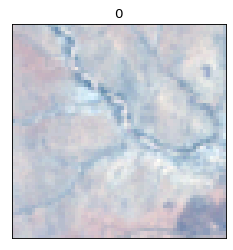

In [116]:
plot_sat_imgs_plt(parsed_examples, channels=':')